# Practical Execution Task — Data Science
**Prepared by:** JobAxle  
**Dataset:** Titanic    
**submitted by** Aardish Duwal  
**Email** aardish01@gmail.com

## Task 1: Load CSV Dataset and Perform Basic EDA

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print('=== HEAD ===')
print(df.head())

print('\n=== INFO ===')
df.info()

print('\n=== DESCRIBE ===')
print(df.describe())

=== HEAD ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

## Task 2: Handle Missing Values Using Multiple Strategies

In [17]:
print('Missing values before handling:')
print(df.isnull().sum())

# Strategy 1: Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Strategy 2: Fill Fare with median (dataset has at least one missing Fare)
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Strategy 3: Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Strategy 4: Drop Cabin column (too many missing)
df.drop(columns=['Cabin'], inplace=True)

print('\nMissing values after handling:')
print(df.isnull().sum())

Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Task 3: Detect and Remove Duplicate Rows

In [18]:
print(f'Duplicate rows found: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows found: 0
Shape after removing duplicates: (891, 11)


## Task 4: Perform Label Encoding and One-Hot Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Label Encoding — Sex
le = LabelEncoder()
df_encoded['Sex_Label'] = le.fit_transform(df_encoded['Sex'])
print('Label Encoding (Sex):')
print(df_encoded[['Sex', 'Sex_Label']].drop_duplicates())

# One-Hot Encoding — Embarked
embarked_ohe = pd.get_dummies(df_encoded['Embarked'], prefix='Embarked')
df_encoded = pd.concat([df_encoded, embarked_ohe], axis=1)
print('\nOne-Hot Encoding (Embarked) columns added:')
print(embarked_ohe.head())

Label Encoding (Sex):
      Sex  Sex_Label
0    male          1
1  female          0

One-Hot Encoding (Embarked) columns added:
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


## Task 5: Create Visualizations (Bar, Line, Scatter)

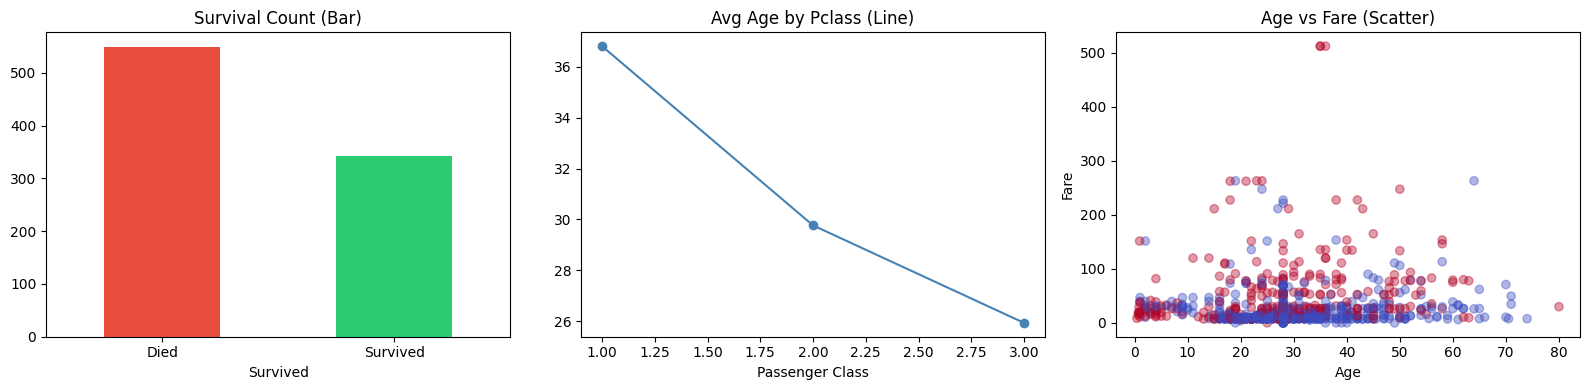

Saved as visualizations.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart — Survival count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Survival Count (Bar)')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

# Line chart — Average age by Pclass
df.groupby('Pclass')['Age'].mean().plot(kind='line', ax=axes[1], marker='o', color='steelblue')
axes[1].set_title('Avg Age by Pclass (Line)')
axes[1].set_xlabel('Passenger Class')

# Scatter chart — Age vs Fare
axes[2].scatter(df['Age'], df['Fare'], alpha=0.4, c=df['Survived'], cmap='coolwarm')
axes[2].set_title('Age vs Fare (Scatter)')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Fare')

plt.tight_layout()
plt.savefig('visualizations.png')
plt.show()
print('Saved as visualizations.png')

## Task 6: Identify and Treat Outliers Using Boxplot

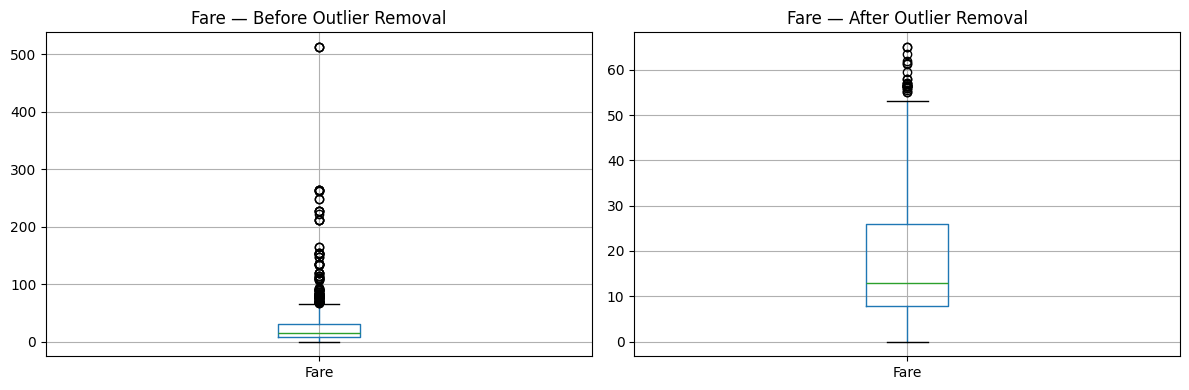

Rows before: 891, after: 775
Using outlier-filtered dataframe for the remaining tasks.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
df.boxplot(column='Fare', ax=axes[0])
axes[0].set_title('Fare — Before Outlier Removal')

# IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_clean = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

# After
df_clean.boxplot(column='Fare', ax=axes[1])
axes[1].set_title('Fare — After Outlier Removal')

plt.tight_layout()
plt.savefig('outliers.png')
plt.show()
print(f'Rows before: {len(df)}, after: {len(df_clean)}')

# Continue modeling on rows without Fare outliers
df = df_clean.copy()
print('Using outlier-filtered dataframe for the remaining tasks.')

## Task 7: Perform Feature Engineering (Create New Columns)

In [22]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                    'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
df['Title'] = df['Title'].fillna('Unknown')

print('New features created:')
print(df[['Name', 'FamilySize', 'IsAlone', 'Title']].head(10))

New features created:
                                                 Name  FamilySize  IsAlone  \
0                             Braund, Mr. Owen Harris           2        0   
2                              Heikkinen, Miss. Laina           1        1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)           2        0   
4                            Allen, Mr. William Henry           1        1   
5                                    Moran, Mr. James           1        1   
6                             McCarthy, Mr. Timothy J           1        1   
7                      Palsson, Master. Gosta Leonard           5        0   
8   Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)           3        0   
9                 Nasser, Mrs. Nicholas (Adele Achem)           2        0   
10                    Sandstrom, Miss. Marguerite Rut           3        0   

     Title  
0       Mr  
2     Miss  
3      Mrs  
4       Mr  
5       Mr  
6       Mr  
7   Master  
8      Mrs  
9 

## Task 8: Apply Normalization and Standardization

In [23]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

age_mm_scaler = MinMaxScaler()
fare_mm_scaler = MinMaxScaler()
age_std_scaler = StandardScaler()
fare_std_scaler = StandardScaler()

df['Age_Normalized'] = age_mm_scaler.fit_transform(df[['Age']])
df['Fare_Normalized'] = fare_mm_scaler.fit_transform(df[['Fare']])

df['Age_Standardized'] = age_std_scaler.fit_transform(df[['Age']])
df['Fare_Standardized'] = fare_std_scaler.fit_transform(df[['Fare']])

print(df[['Age', 'Age_Normalized', 'Age_Standardized',
          'Fare', 'Fare_Normalized', 'Fare_Standardized']].head())

    Age  Age_Normalized  Age_Standardized     Fare  Fare_Normalized  \
0  22.0        0.271174         -0.528321   7.2500         0.111538   
2  26.0        0.321438         -0.215182   7.9250         0.121923   
3  35.0        0.434531          0.489381  53.1000         0.816923   
4  35.0        0.434531          0.489381   8.0500         0.123846   
5  28.0        0.346569         -0.058613   8.4583         0.130128   

   Fare_Standardized  
0          -0.779117  
2          -0.729373  
3           2.599828  
4          -0.720161  
5          -0.690071  


## Task 9: Split Dataset into Train/Test

In [24]:
from sklearn.model_selection import train_test_split

# Prepare features
features = ['Pclass', 'Age_Standardized', 'Fare_Standardized',
            'SibSp', 'Parch', 'FamilySize', 'IsAlone']
# Label encode Sex for model (keep encoder for exporting to API)
sex_label_encoder = LabelEncoder()
df['Sex_enc'] = sex_label_encoder.fit_transform(df['Sex'])
features.append('Sex_enc')

# Drop any row with NaN in model inputs (e.g. if cells were run out of order)
_nan = df[features].isna().any(axis=1).sum()
if _nan:
    print(f'Dropping {_nan} row(s) with NaN in features before train/test split')
df = df.dropna(subset=features)

X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (620, 8)
Test set:     (155, 8)


## Task 10: Train a Logistic Regression Model and Evaluate

Logistic Regression Accuracy: 0.7935

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       102
           1       0.71      0.66      0.69        53

    accuracy                           0.79       155
   macro avg       0.77      0.76      0.77       155
weighted avg       0.79      0.79      0.79       155



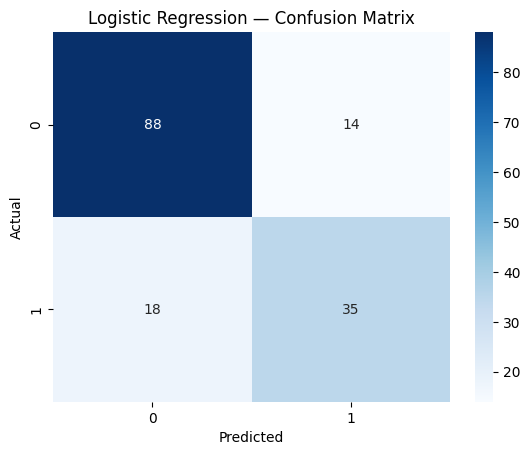

Saved model_artifacts.joblib


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print(f'Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred))

# Confusion matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('lr_confusion_matrix.png')
plt.show()

# Save artifacts for FastAPI (same bundle as build_artifacts.py)
import joblib
joblib.dump(
    {
        'model': lr_model,
        'feature_names': features,
        'age_std_scaler': age_std_scaler,
        'fare_std_scaler': fare_std_scaler,
        'sex_label_encoder': sex_label_encoder,
    },
    'model_artifacts.joblib',
)
print('Saved model_artifacts.joblib')

## Task 11: Implement Decision Tree and Compare Results

Decision Tree Accuracy:    0.8194
Logistic Regression Acc:   0.7935


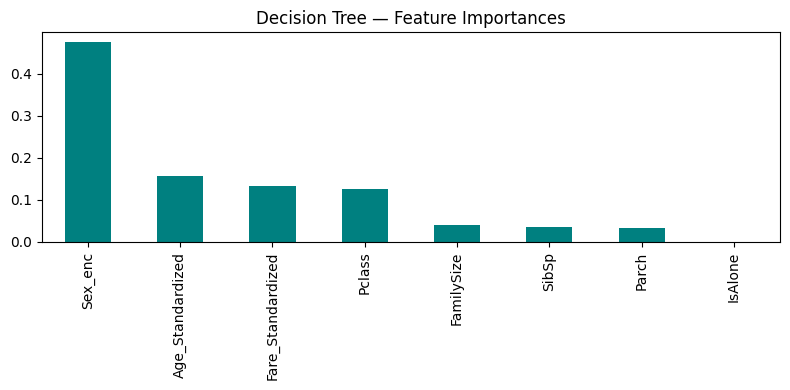

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print(f'Decision Tree Accuracy:    {accuracy_score(y_test, dt_pred):.4f}')
print(f'Logistic Regression Acc:   {accuracy_score(y_test, lr_pred):.4f}')

# Feature importance
feat_imp = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='teal', figsize=(8,4))
plt.title('Decision Tree — Feature Importances')
plt.tight_layout()
plt.savefig('dt_feature_importance.png')
plt.show()

## Task 12: Apply K-Means Clustering and Use Elbow Method

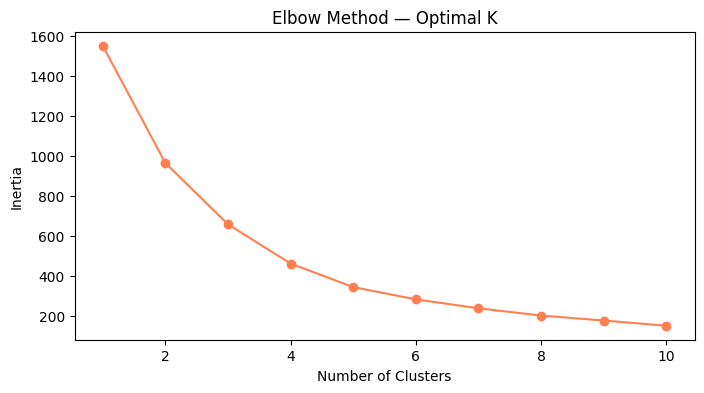

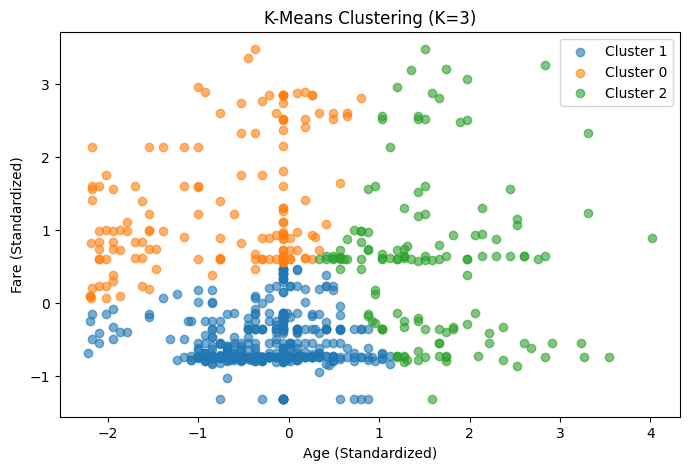

In [27]:
from sklearn.cluster import KMeans

X_cluster = df[['Age_Standardized', 'Fare_Standardized']].dropna().copy()

# Elbow method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, marker='o', color='coral')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('elbow_method.png')
plt.show()

# Apply K=3 (elbow usually around 3)
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
X_cluster['Cluster'] = km_final.fit_predict(X_cluster)

plt.figure(figsize=(8,5))
for c in X_cluster['Cluster'].unique():
    subset = X_cluster[X_cluster['Cluster'] == c]
    plt.scatter(subset['Age_Standardized'], subset['Fare_Standardized'], label=f'Cluster {c}', alpha=0.6)
plt.title('K-Means Clustering (K=3)')
plt.xlabel('Age (Standardized)')
plt.ylabel('Fare (Standardized)')
plt.legend()
plt.savefig('kmeans_clusters.png')
plt.show()

## Task 13: Build a Simple API Using FastAPI to Serve Predictions

The repository includes `app.py`, which loads `model_artifacts.joblib` (saved by the cell above or by `python build_artifacts.py`) and returns **real** model predictions.

Run the API: `python -m uvicorn app:app --reload` or `python app.py` (see `README.md` for `PORT` if 8000 is busy). Then open `/docs` and **POST** `/predict`.

In [28]:
# app.py lives in the project root and is maintained there (not generated here).
# Ensure model_artifacts.joblib exists (saved in Task 10 cell), then from a terminal run:
#   python -m uvicorn app:app --reload   OR   python app.py
print('After model_artifacts.joblib exists: run "python -m uvicorn app:app --reload" or "python app.py" (see README).')

Use the app.py file in this folder with uvicorn after model_artifacts.joblib is present.


## Task 14: Scrape Data Using Requests + BeautifulSoup and Export CSV

In [29]:
import requests
from bs4 import BeautifulSoup

# Scrape a public table from Wikipedia
url = 'https://en.wikipedia.org/wiki/Titanic'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
soup = BeautifulSoup(response.text, 'html.parser')

# Extract all tables
tables = soup.find_all('table', class_='wikitable')
print(f'Found {len(tables)} wikitables on the page')

# Parse first table
if tables:
    rows = tables[0].find_all('tr')
    data = []
    for row in rows:
        cols = [col.get_text(strip=True) for col in row.find_all(['th','td'])]
        if cols:
            data.append(cols)
    scraped_df = pd.DataFrame(data[1:], columns=data[0] if data else None)
    scraped_df.to_csv('scraped_data.csv', index=False)
    print('Scraped table exported to scraped_data.csv')
    print(scraped_df.head())
else:
    print('No tables found — try a different URL')

Found 1 wikitables on the page
Scraped table exported to scraped_data.csv
        Sex/Age   Class/crew Number aboard Number saved Number lost  \
0      Children  First Class             7            6           1   
1  Second Class           26            25            1         96%   
2   Third Class           89            32           57         36%   
3          Crew            2             0            2          0%   
4         Women  First Class           142          138           4   

  Percentage saved Percentage lost  
0              86%             14%  
1               4%            None  
2              64%            None  
3             100%            None  
4              97%              3%  


## Task 15: Automate Browser Task Using Selenium (Login/Data Extraction)

The script `selenium_task.py` logs into the public demo at [the-internet.herokuapp.com/login](https://the-internet.herokuapp.com/login) using its published test credentials, then opens the home page and prints extracted text.

> **Browser:** **Microsoft Edge only** (headless). Selenium uses `webdriver.Edge`; do not use Chrome or Brave for this script. Selenium 4+ resolves **msedgedriver** in most setups.

In [30]:
# Run from terminal: python selenium_task.py (see selenium_task.py in this folder)
print('Selenium demo: python selenium_task.py')

Selenium demo: python selenium_task.py


---
## Summary

| Task | Description | Status |
|------|-------------|--------|
| 1 | Load CSV & EDA | ✅ Done |
| 2 | Handle Missing Values | ✅ Done |
| 3 | Remove Duplicates | ✅ Done |
| 4 | Label & One-Hot Encoding | ✅ Done |
| 5 | Visualizations (Bar/Line/Scatter) | ✅ Done |
| 6 | Outlier Detection & Treatment | ✅ Done |
| 7 | Feature Engineering | ✅ Done |
| 8 | Normalization & Standardization | ✅ Done |
| 9 | Train/Test Split | ✅ Done |
| 10 | Logistic Regression | ✅ Done |
| 11 | Decision Tree + Comparison | ✅ Done |
| 12 | K-Means + Elbow Method | ✅ Done |
| 13 | FastAPI Prediction API | ✅ `app.py` + `model_artifacts.joblib` |
| 14 | Web Scraping + Export CSV | ✅ Done |
| 15 | Selenium Login + Extraction | ✅ `selenium_task.py` |